# Cyber Threat Intelligence Extraction using NLP
**B.Tech Project Group 51, Cyber Security Case Study**: Ayaan Rukadikar, Viraj Sheoran, Chintan Pradhan, Deep Shah

A scaled-down, runnable demonstration of the pipeline in our case study report. Each stage maps to a report section and produces one visible result.

**Pipeline:** Data (DNRTI, MITRE ATT&CK) → Tokenizer study → NER fine-tuning → ATT&CK technique mapping → STIX 2.1 export and knowledge graph → Summary

**Scope note:** run on a MacBook Air M4 with no LLM API. NER uses a data subset and 2 epochs, and technique mapping uses embedding similarity without the LLM verification step. All numbers are our own measurements, shown next to the paper's cited values.

## Stage 0: Setup (Report Sec 4.1, 4.3)
Imports, random seeds, device selection (Apple MPS GPU) and run settings. Training is limited to 3,000 sentences, 2 epochs and max length 128 so it fits a laptop. The report used 4x A100 GPUs, 30 epochs and max length 512.

In [1]:
import os, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
warnings.filterwarnings("ignore")

import re, json, random, glob, subprocess, requests
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

os.makedirs("data", exist_ok=True); os.makedirs("out", exist_ok=True)
random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

# ---- Run settings -------------------------------------------------------
# Default (fast, ~3 min per model): 3000, 2, 128, 16
# Fairer run (~15-20 min per model): 5430, 5, 128, 16  and set RETRAIN = True
MAX_TRAIN, EPOCHS, MAXLEN, BATCH = 3000, 2, 128, 16
RETRAIN = False          # True = delete cached NER results and train again
SIM_THRESHOLD = 0.50     # minimum cosine similarity to accept a technique match
MODELS = {"RoBERTa-base": "roberta-base", "SecureBERT": "ehsanaghaei/SecureBERT"}

device: mps


## Stage 1: Data, the DNRTI benchmark (Report Sec 2.1, 4.2, Tables 6-7)
DNRTI is the benchmark the report uses for CTI named entity recognition. The repo ships it as a `.rar` archive, so we download and extract it, then parse the token-per-line format with BIO labels (for example `B-HackOrg` marks the start of a threat-actor name). Expected: 5,430 training and 680 test sentences.

files: ['data/dnrti/train.txt', 'data/dnrti/valid.txt', 'data/dnrti/test.txt']
train: 5430 sentences | test: 680 sentences | 27 BIO labels


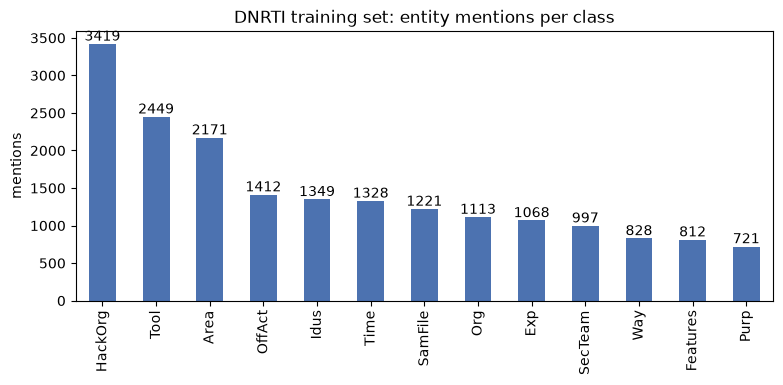

,sentence,entities
0,The admin@338 has largely targeted organizatio...,"[(admin@338, B-HackOrg), (financial, B-Idus), ..."
1,The admin@338 started targeting Hong Kong medi...,"[(admin@338, B-HackOrg), (Hong, B-Area), (Kong..."
2,Multiple China-based cyber threat groups have ...,"[(China-based, B-Area), (cyber, B-HackOrg), (t..."


In [2]:
REPO = "SCreaMxp/DNRTI-A-Large-scale-Dataset-for-Named-Entity-Recognition-in-Threat-Intelligence"
rar = "data/DNRTI.rar"
if not os.path.exists(rar):
    open(rar, "wb").write(requests.get(f"https://github.com/{REPO}/raw/master/DNRTI.rar").content)

def listing():
    return [p for p in glob.glob("data/dnrti/**/*", recursive=True) if os.path.isfile(p)]

os.makedirs("data/dnrti", exist_ok=True)
if not listing():
    subprocess.run(["tar", "-xf", rar, "-C", "data/dnrti"], capture_output=True)    # macOS built-in
if not listing():
    subprocess.run(["unar", "-o", "data/dnrti", rar], capture_output=True)          # needs: brew install unar
files = listing()
print("files:", files)

def find(*keys):
    c = [p for p in files if any(k in os.path.basename(p).lower() for k in keys)]
    return c[0] if c else None

def load_conll(path):
    sents, toks, labs = [], [], []
    for line in open(path, encoding="utf-8", errors="ignore").read().splitlines():
        parts = line.split()
        if len(parts) < 2:
            if toks: sents.append((toks, labs)); toks, labs = [], []
        else:
            toks.append(parts[0]); labs.append(parts[-1])
    if toks: sents.append((toks, labs))
    return sents

train, test = load_conll(find("train")), load_conll(find("test"))
labels = sorted({l for _, ls in train + test for l in ls})
print(f"train: {len(train)} sentences | test: {len(test)} sentences | {len(labels)} BIO labels")

counts = pd.Series([l[2:] for _, ls in train for l in ls if l.startswith("B-")]).value_counts()
ax = counts.plot(kind="bar", figsize=(9, 3.5), color="#4C72B0", title="DNRTI training set: entity mentions per class")
ax.bar_label(ax.containers[0]); plt.ylabel("mentions")
plt.savefig("out/dnrti_distribution.png", dpi=150, bbox_inches="tight"); plt.show()
pd.DataFrame([{"sentence": " ".join(t)[:110], "entities": [(w, l) for w, l in zip(t, ls) if l != "O"][:4]} for t, ls in train[:3]])

## Stage 2: Tokenizer study (Report Sec 3.2, Table 4, Fig. 2)
The report argues that general tokenizers split security terms into meaningless fragments, and that SecureBERT's extended vocabulary fixes this. We test it directly: fewer pieces means the term is kept whole. The effect is partial. "ransomware" and "obfuscated" become single tokens, but the CVE ID is still fragmented by both models.

,RoBERTa-base pieces,SecureBERT pieces,RoBERTa-base tokens,SecureBERT tokens
term,,,,
ransomware,3,1,r ansom ware,ransomware
obfuscated,3,1,ob fusc ated,obfuscated
spearphishing,4,3,spe ar ph ishing,sp ear phishing
cve-2023-38831,8,8,c ve - 20 23 - 388 31,cve - 20 23 - 3 88 31
mimikatz,4,3,m im ik atz,m im ikatz


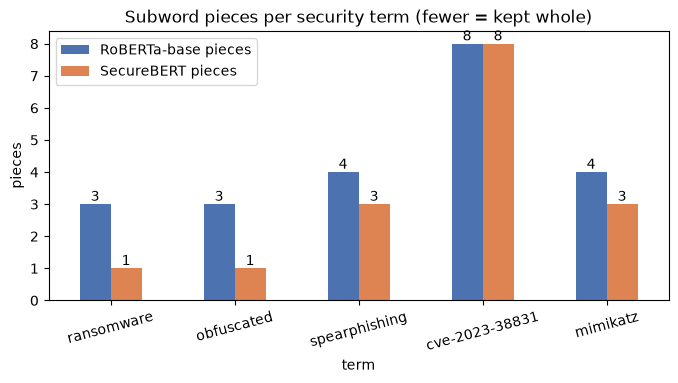

In [3]:
from transformers import AutoTokenizer
terms = ["ransomware", "obfuscated", "spearphishing", "cve-2023-38831", "mimikatz"]
tks = {n: AutoTokenizer.from_pretrained(m) for n, m in MODELS.items()}
tok_df = pd.DataFrame([{"term": t,
                        **{f"{n} pieces": len(tk.tokenize(t)) for n, tk in tks.items()},
                        **{f"{n} tokens": " ".join(tk.tokenize(t)) for n, tk in tks.items()}} for t in terms]).set_index("term")
display(tok_df)
ax = tok_df[[f"{n} pieces" for n in MODELS]].plot(kind="bar", rot=15, figsize=(8, 3.5), color=["#4C72B0", "#DD8452"],
                                                   title="Subword pieces per security term (fewer = kept whole)")
for c in ax.containers: ax.bar_label(c)
plt.ylabel("pieces"); plt.savefig("out/tokenizer_pieces.png", dpi=150, bbox_inches="tight"); plt.show()

## Stage 3: NER fine-tuning, RoBERTa-base vs SecureBERT (Report Sec 3.3, 4.4, 5.1, Table 9, Fig. 4)
SecureBERT is a RoBERTa model with domain-adaptive pre-training, so comparing the two isolates the effect of domain adaptation. Metrics are entity-level micro precision, recall and F1 (seqeval). Results are cached in `out/ner_results.json`, so re-runs skip training. Deviations from the report: no CRF layer, a data subset, 2 epochs.

,P,R,F1
RoBERTa-base,0.672,0.690,0.681
SecureBERT,0.638,0.619,0.628


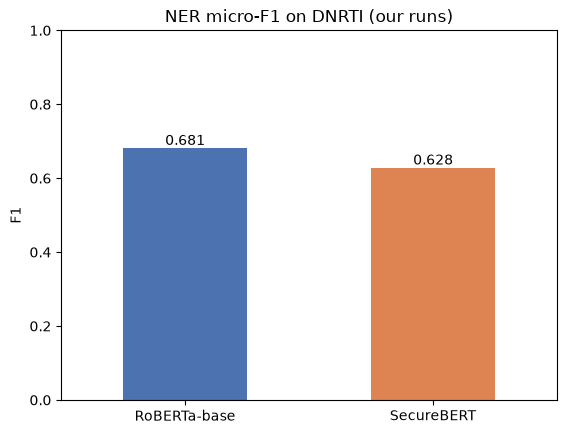

In [4]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from seqeval.metrics import precision_score, recall_score, f1_score

l2i = {l: i for i, l in enumerate(labels)}
train_sub = random.sample(train, min(MAX_TRAIN, len(train)))

def encode(tok, data):
    out = []
    for words, labs in data:
        enc = tok(words, is_split_into_words=True, truncation=True, max_length=MAXLEN)
        prev, lab = None, []
        for w in enc.word_ids():
            lab.append(-100 if (w is None or w == prev) else l2i[labs[w]]); prev = w
        out.append({"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"], "labels": lab})
    return out

RES = "out/ner_results.json"
if RETRAIN and os.path.exists(RES): os.remove(RES)
results = json.load(open(RES)) if os.path.exists(RES) else {}

for name, mid in MODELS.items():
    if name in results: continue
    tok = AutoTokenizer.from_pretrained(mid, add_prefix_space=True)
    model = AutoModelForTokenClassification.from_pretrained(
        mid, num_labels=len(labels), id2label={i: l for l, i in l2i.items()}, label2id=l2i)
    total_steps = (len(train_sub) // BATCH + 1) * EPOCHS
    args = TrainingArguments(output_dir=f"out/{name}", per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=32, num_train_epochs=EPOCHS, learning_rate=5e-5,
        weight_decay=0.01, warmup_steps=int(0.1 * total_steps), save_strategy="no",
        report_to="none", logging_steps=50)
    tr = Trainer(model=model, args=args, train_dataset=encode(tok, train_sub),
                 data_collator=DataCollatorForTokenClassification(tok))
    tr.train()
    pred = tr.predict(encode(tok, test))
    yt, yp = [], []
    for p, l in zip(pred.predictions.argmax(-1), pred.label_ids):
        m = l != -100
        yt.append([labels[i] for i in l[m]]); yp.append([labels[i] for i in p[m]])
    results[name] = {"P": precision_score(yt, yp), "R": recall_score(yt, yp), "F1": f1_score(yt, yp)}
    tr.save_model(f"out/{name}_model"); tok.save_pretrained(f"out/{name}_model")
    json.dump(results, open(RES, "w"))
    del model, tr
    if device == "mps": torch.mps.empty_cache()

ner_df = pd.DataFrame(results).T.round(3)
display(ner_df.style.format("{:.3f}").background_gradient(cmap="Blues"))
ax = ner_df["F1"].plot(kind="bar", ylim=(0, 1), color=["#4C72B0", "#DD8452"], rot=0, title="NER micro-F1 on DNRTI (our runs)")
ax.bar_label(ax.containers[0], fmt="%.3f"); ax.set_ylabel("F1")
plt.savefig("out/ner_f1.png", dpi=150, bbox_inches="tight"); plt.show()

### Stage 3b: Per-entity analysis
Which entity types does the best model find easily, and which does it miss? Rare classes usually score lower, which matches the class imbalance the report describes in Table 7.

,precision,recall,f1-score,support
Purp,0.371,0.339,0.355,115.0
Features,0.433,0.448,0.441,116.0
SamFile,0.573,0.411,0.479,248.0
Org,0.543,0.504,0.523,137.0
Tool,0.536,0.638,0.583,315.0
Way,0.774,0.650,0.707,100.0
Idus,0.746,0.682,0.713,129.0
HackOrg,0.673,0.808,0.734,369.0
OffAct,0.730,0.793,0.760,150.0
Time,0.828,0.828,0.828,169.0


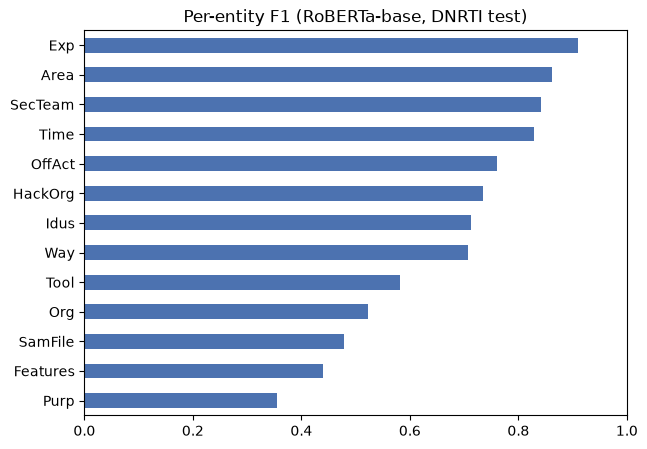

In [5]:
from seqeval.metrics import classification_report
best = max(results, key=lambda k: results[k]["F1"])
tok_b = AutoTokenizer.from_pretrained(f"out/{best}_model", add_prefix_space=True)
mdl_b = AutoModelForTokenClassification.from_pretrained(f"out/{best}_model")
tr_b = Trainer(model=mdl_b, args=TrainingArguments(output_dir="out/tmp", per_device_eval_batch_size=32, report_to="none"),
               data_collator=DataCollatorForTokenClassification(tok_b))
pred = tr_b.predict(encode(tok_b, test))
yt, yp = [], []
for p, l in zip(pred.predictions.argmax(-1), pred.label_ids):
    m = l != -100
    yt.append([labels[i] for i in l[m]]); yp.append([labels[i] for i in p[m]])
rep = pd.DataFrame(classification_report(yt, yp, output_dict=True)).T
per_ent = rep.drop(["micro avg", "macro avg", "weighted avg"]).sort_values("f1-score")
display(per_ent[["precision", "recall", "f1-score", "support"]].round(3))
ax = per_ent["f1-score"].plot(kind="barh", figsize=(7, 5), color="#4C72B0", title=f"Per-entity F1 ({best}, DNRTI test)")
ax.set_xlim(0, 1); plt.savefig("out/ner_per_entity.png", dpi=150, bbox_inches="tight"); plt.show()

## Stage 4: MITRE ATT&CK data and a labeled test set (Report Sec 2.3, 4.2)
We load the current ATT&CK techniques. For labeled test sentences without manual annotation, we use MITRE's own procedure examples: real-world sentences describing how a named malware, tool or group uses a technique, each labeled with its technique ID.

In [6]:
ATT = "data/enterprise-attack.json"
if not os.path.exists(ATT):
    open(ATT, "wb").write(requests.get("https://raw.githubusercontent.com/mitre-attack/attack-stix-data/HEAD/enterprise-attack/enterprise-attack.json").content)
objs = json.load(open(ATT))["objects"]

def clean(t):
    t = re.sub(r"\(Citation:[^)]*\)", "", t)
    t = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", t)
    return re.sub(r"\s+", " ", t).strip()

tech = {}
for o in objs:
    if o["type"] == "attack-pattern" and not o.get("revoked") and not o.get("x_mitre_deprecated"):
        tid = next((r["external_id"] for r in o.get("external_references", []) if r.get("source_name") == "mitre-attack"), None)
        if tid: tech[o["id"]] = {"tid": tid, "name": o["name"], "desc": clean(o.get("description", ""))}

tests = []
for o in objs:
    if (o["type"] == "relationship" and o.get("relationship_type") == "uses" and not o.get("revoked")
            and o["target_ref"] in tech and o["source_ref"].split("--")[0] in ("intrusion-set", "malware", "tool")):
        d = clean(o.get("description", ""))
        if 40 < len(d) < 400: tests.append((d, tech[o["target_ref"]]["tid"]))
random.shuffle(tests); tests = tests[:500]
print(f"{len(tech)} techniques | {len(tests)} labeled test sentences")
pd.DataFrame([{"sentence": s[:100], "technique": f'{t} {next(v["name"] for v in tech.values() if v["tid"] == t)}'} for s, t in tests[:4]])

697 techniques | 500 labeled test sentences


,sentence,technique
0,CSPY Downloader has the ability to remove valu...,T1070 Indicator Removal
1,VOID MANTICORE has utilized legitimate disk en...,T1486 Data Encrypted for Impact
2,BADHATCH can utilize the CMSTPLUA COM interfac...,T1548.002 Bypass User Account Control
3,BitPaymer can suppress UAC prompts by setting ...,T1548.002 Bypass User Account Control


## Stage 5: Technique mapping, TF-IDF+SVM vs embedding similarity (Report Sec 2.3, 3.4, 5.2, Table 11)
Both methods only see technique definitions during training or matching, then are tested on real usage sentences. That recreates the cross-domain gap from Report Sec 5.3. Embedding similarity corresponds to step 3 (candidate generation) of the report's four-step pipeline. The LLM verification step is not implemented, since no API was available.

,Top-1 acc,Macro-F1,Top-5 acc
TF-IDF + SVM,0.300,0.177,-
MiniLM embedding similarity,0.360,0.212,0.596


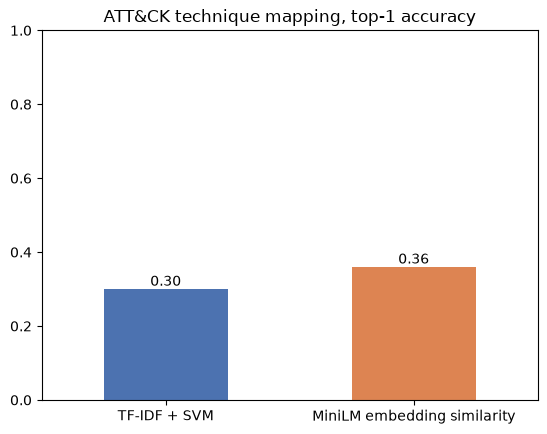

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score as skf1, accuracy_score
from sentence_transformers import SentenceTransformer

tids = [v["tid"] for v in tech.values()]
Xtr, ytr = [], []
for v in tech.values():
    for s in re.split(r"(?<=[.!?])\s+", v["name"] + ". " + v["desc"]):
        if len(s) > 20: Xtr.append(s); ytr.append(v["tid"])
Xte, yte = [t[0] for t in tests], [t[1] for t in tests]

vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, stop_words="english")
svm = LinearSVC().fit(vec.fit_transform(Xtr), ytr)
p_svm = svm.predict(vec.transform(Xte))

emb = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")
E_t = emb.encode([v["name"] + ". " + v["desc"] for v in tech.values()], normalize_embeddings=True)
E_s = emb.encode(Xte, normalize_embeddings=True)
sim = E_s @ E_t.T
p_emb = [tids[i] for i in sim.argmax(1)]
top5 = np.mean([y in [tids[j] for j in np.argsort(-r)[:5]] for r, y in zip(sim, yte)])

ttp_df = pd.DataFrame({
    "TF-IDF + SVM": {"Top-1 acc": accuracy_score(yte, p_svm), "Macro-F1": skf1(yte, p_svm, average="macro", zero_division=0)},
    "MiniLM embedding similarity": {"Top-1 acc": accuracy_score(yte, p_emb), "Macro-F1": skf1(yte, p_emb, average="macro", zero_division=0), "Top-5 acc": top5},
}).T
display(ttp_df.style.format("{:.3f}", na_rep="-").background_gradient(cmap="Greens"))
ax = ttp_df["Top-1 acc"].plot(kind="bar", ylim=(0, 1), color=["#4C72B0", "#DD8452"], rot=0, title="ATT&CK technique mapping, top-1 accuracy")
ax.bar_label(ax.containers[0], fmt="%.2f"); plt.savefig("out/ttp_top1.png", dpi=150, bbox_inches="tight"); plt.show()

### Stage 5b: Threshold trade-off and error analysis
Raising the similarity threshold keeps fewer sentences but those matches are more accurate. This is the same precision-over-recall idea behind the report's thresholded verification step. The table lists wrong predictions, which are usually related techniques and show why an LLM verification step is needed.

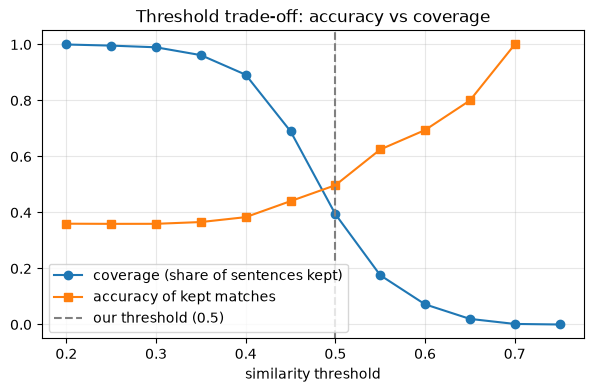

,sentence,true technique,predicted technique
0,CSPY Downloader has the ability to remove valu...,T1070 Indicator Removal,T1552.002 Credentials in Registry
1,VOID MANTICORE has utilized legitimate disk en...,T1486 Data Encrypted for Impact,T1561.001 Disk Content Wipe
2,Gamaredon Group has checked existing condition...,T1497.001 System Checks,T1595.003 Wordlist Scanning
3,LunarLoader can use the DNS domain name of a c...,T1480 Execution Guardrails,T1584.002 DNS Server
4,AppleSeed has automatically collected data fro...,T1119 Automated Collection,T1025 Data from Removable Media
5,Gold Dragon collects endpoint information usin...,T1082 System Information Discovery,T1057 Process Discovery


In [8]:
best_sim = sim.max(1)
correct = np.array([p == y for p, y in zip(p_emb, yte)])
ths = np.arange(0.20, 0.76, 0.05)
cov = [(best_sim >= t).mean() for t in ths]
acc = [correct[best_sim >= t].mean() if (best_sim >= t).any() else np.nan for t in ths]
plt.figure(figsize=(7, 4))
plt.plot(ths, cov, "o-", label="coverage (share of sentences kept)")
plt.plot(ths, acc, "s-", label="accuracy of kept matches")
plt.axvline(SIM_THRESHOLD, color="gray", ls="--", label=f"our threshold ({SIM_THRESHOLD})")
plt.xlabel("similarity threshold"); plt.legend(); plt.grid(alpha=0.3); plt.title("Threshold trade-off: accuracy vs coverage")
plt.savefig("out/ttp_threshold.png", dpi=150, bbox_inches="tight"); plt.show()

name_of = {v["tid"]: v["name"] for v in tech.values()}
wrong = [(Xte[i][:90], f"{yte[i]} {name_of[yte[i]]}", f"{p_emb[i]} {name_of[p_emb[i]]}") for i in np.where(~correct)[0][:6]]
pd.DataFrame(wrong, columns=["sentence", "true technique", "predicted technique"])

## Stage 6: End-to-end demo and STIX 2.1 export (Report Sec 3.4, 6, Table 14, Figs. 6-7)
One sample threat report goes through: NER → technique mapping (similarity ≥ threshold) → STIX 2.1 objects (threat-actor, malware, vulnerability, attack-pattern) and relationships → knowledge graph. CVE IDs are taken by regex because subword NER splits them. Relationships are rule-based and document-level (every actor is linked to every tool and technique found), not true relation extraction. The bundle is saved to `out/bundle.json` and validated by parsing it back.

using NER model: RoBERTa-base
Entities found by NER:


,type,text
0,HackOrg,APT28
1,Way,spear-phishing emails
2,Org,government
3,HackOrg,group
4,Tool,X-Agent malware
5,HackOrg,attackers
6,Tool,Mimikatz
7,Purp,dump credentials
8,OffAct,campaign
9,Exp,CVE


Technique mapping:


,sentence,technique,score
0,APT28 sent spear-phishing emails with a malici...,T1598.003 Spearphishing Link,0.53
1,The group deployed X-Agent malware on compromi...,no match,0.45
2,The malware modified registry keys to achieve ...,T1070.009 Clear Persistence,0.63
3,The attackers then used Mimikatz to dump crede...,T1003.001 LSASS Memory,0.59
4,The campaign exploited CVE-2017-0144 in unpatc...,no match,0.48


STIX 2.1 validation passed: 13 objects parsed back from the bundle
{
    "type": "bundle",
    "id": "bundle--eeb6eff4-e8da-4099-9a2e-14bb14ed9675",
    "objects": [
        {
            "type": "threat-actor",
            "spec_version": "2.1",
            "id": "threat-actor--ea308973-6223-4e3d-aa5a-36c06d559eea",
            "created": "2026-10-09T14:43:46.236278Z",
            "modified": "2026-10-09T14:43:46.236278Z",
            "name": "APT28"
        },
        {
            "type": "malware",
            "spec_version": "2.1",
            "id": "malware--798963bb-66a0-40ef-a508-90ccebb31181",
            "created": "2026-10-09T14:43:46.236611Z",
            "modified": "2026-10-09T14:43:46.236611Z",
            "name": "Mimikatz",
            "is_family": false
        },
        {
            "type": "malware",
            "spec_version": "2.1",
            "id": "malware--afbf4ec4-ea11-4faa-9f8e-3a47b4b4cd48",
            "created": "2026-10-09T14:43:46.236741Z",
          

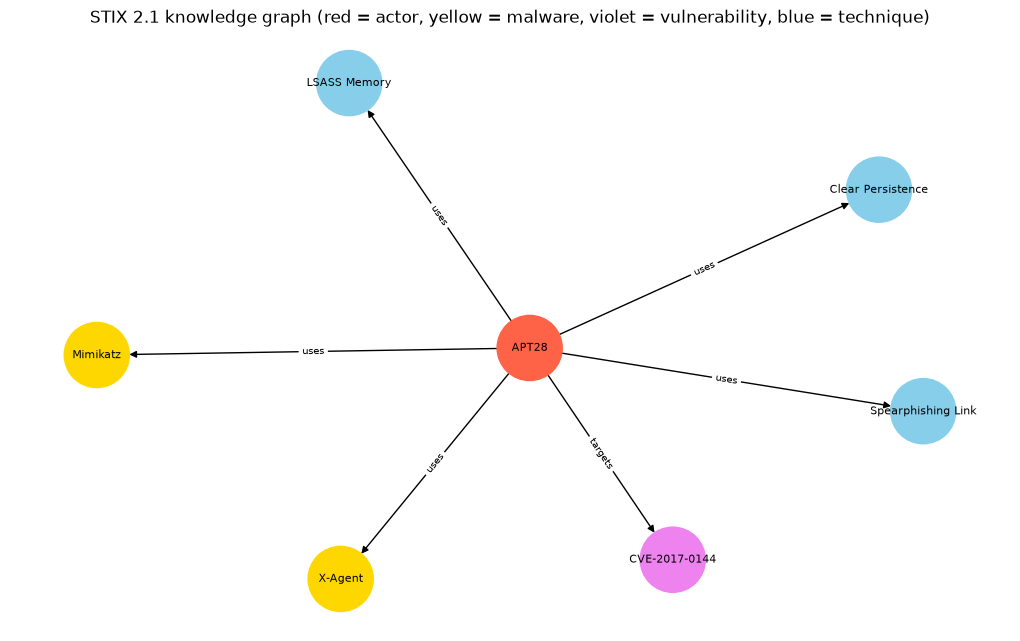

In [9]:
from transformers import pipeline
import stix2, networkx as nx

print("using NER model:", best)
ner = pipeline("token-classification", model=f"out/{best}_model", tokenizer=f"out/{best}_model",
               aggregation_strategy="simple", device=-1)

report = ("APT28 sent spear-phishing emails with a malicious attachment to government targets. "
          "The group deployed X-Agent malware on compromised hosts. "
          "The malware modified registry keys to achieve persistence. "
          "The attackers then used Mimikatz to dump credentials from memory. "
          "The campaign exploited CVE-2017-0144 in unpatched Windows systems.")
sents = re.split(r"(?<=[.!?])\s+", report)

ents, ttp_rows, found = [], [], {}
tech_list = list(tech.values())
for s in sents:
    for e in ner(s): ents.append((e["entity_group"], e["word"].strip()))
    v = emb.encode([s], normalize_embeddings=True)[0] @ E_t.T
    i = int(v.argmax()); t = tech_list[i]
    ok = v[i] >= SIM_THRESHOLD
    ttp_rows.append({"sentence": s[:70] + "...", "technique": f'{t["tid"]} {t["name"]}' if ok else "no match", "score": round(float(v[i]), 2)})
    if ok: found[t["tid"]] = t["name"]
print("Entities found by NER:"); display(pd.DataFrame(ents, columns=["type", "text"]))
print("Technique mapping:"); display(pd.DataFrame(ttp_rows))

def names(kind): return sorted({w for g, w in ents if g.lower() == kind and w})
actors = [a for a in names("hackorg") if a.lower() not in ("group", "attackers", "the group", "the attackers")] or ["Unknown actor"]
tools_ = sorted({t.replace(" malware", "") for t in names("tool")})
vulns = sorted(set(re.findall(r"CVE-\d{4}-\d{4,7}", report)))

A = [stix2.ThreatActor(name=n) for n in actors]
M = [stix2.Malware(name=n, is_family=False) for n in tools_]
V = [stix2.Vulnerability(name=n) for n in vulns]
P = [stix2.AttackPattern(name=n, external_references=[stix2.ExternalReference(source_name="mitre-attack", external_id=t)]) for t, n in found.items()]
R = [stix2.Relationship(a, "uses", x) for a in A for x in M + P] + [stix2.Relationship(a, "targets", x) for a in A for x in V]
bundle = stix2.Bundle(objects=A + M + V + P + R)
open("out/bundle.json", "w").write(bundle.serialize(pretty=True))
parsed = stix2.parse(bundle.serialize())
print(f"STIX 2.1 validation passed: {len(parsed.objects)} objects parsed back from the bundle")
print(bundle.serialize(pretty=True)[:1200], "...")

G = nx.DiGraph(); nm = {o.id: o.name for o in A + M + V + P}
col = {"threat-actor": "tomato", "malware": "gold", "vulnerability": "violet", "attack-pattern": "skyblue"}
for o in A + M + V + P: G.add_node(o.name, c=col[o.type])
for r in R: G.add_edge(nm[r.source_ref], nm[r.target_ref], label=r.relationship_type)
pos = nx.spring_layout(G, seed=1, k=1.2); plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color=[d["c"] for _, d in G.nodes(data=True)], node_size=2200, font_size=8, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"), font_size=7)
plt.title("STIX 2.1 knowledge graph (red = actor, yellow = malware, violet = vulnerability, blue = technique)")
plt.savefig("out/stix_graph.png", dpi=150, bbox_inches="tight"); plt.show()

## Stage 7: Our results vs the paper's cited values (Report Sec 5, 8)
Our results are lower than the paper's, and SecureBERT does not beat RoBERTa in our short run. We attribute this to the small subset and 2 epochs, and we do not treat it as evidence against the paper. Paper values are quoted from the cited sources and were not reproduced by us.

In [10]:
summary = pd.DataFrame([
    ["NER micro-F1, RoBERTa-base (DNRTI)", results["RoBERTa-base"]["F1"], "0.842"],
    ["NER micro-F1, SecureBERT (DNRTI)", results["SecureBERT"]["F1"], "0.945 (SecureBERT 2.0)"],
    ["TTP macro-F1, TF-IDF + SVM", ttp_df.loc["TF-IDF + SVM", "Macro-F1"], "0.609"],
    ["TTP macro-F1, embedding similarity", ttp_df.loc["MiniLM embedding similarity", "Macro-F1"], "no equivalent"],
    ["TTP multi-step LLM pipeline", np.nan, "0.8228 (not implemented here)"],
], columns=["Metric", "Our result (small setup)", "Paper-cited"])
display(summary.style.format({"Our result (small setup)": "{:.3f}"}, na_rep="n/a").hide(axis="index"))
summary.to_csv("out/summary.csv", index=False)

Metric,Our result (small setup),Paper-cited
"NER micro-F1, RoBERTa-base (DNRTI)",0.681,0.842
"NER micro-F1, SecureBERT (DNRTI)",0.628,0.945 (SecureBERT 2.0)
"TTP macro-F1, TF-IDF + SVM",0.177,0.609
"TTP macro-F1, embedding similarity",0.212,no equivalent
TTP multi-step LLM pipeline,n/a,0.8228 (not implemented here)


## Conclusions and limitations
- The pipeline from raw text to a STIX 2.1 bundle runs end to end on a laptop.
- SecureBERT's vocabulary adaptation is visible in tokenization (Stage 2) but did not improve F1 in our short training run.
- Embedding similarity beats TF-IDF+SVM for technique mapping. Both fall well short of the paper's numbers because of the cross-domain gap.
- Embedding matches can be wrong but related (Stage 5b), which is why the paper adds LLM verification.
- Not implemented (future work): crawling, CRF layer, extra models, LLM verification, model-based relation extraction.